In [36]:
import csv

Загрузка файла с транзакциями:

In [ ]:
def load_transactions(filepath):
  with open(filepath, 'r', encoding='cp1251') as f:
    transactions = []
    reader = csv.reader(f)
    for row in reader:
        items = [item.strip() for item in row if item.strip()]
        if items:
          transactions.append(set(items))
  return transactions

Создаем множество и добавляем туда продукты в виде frozenset-ов из одного элемента:

In [ ]:
def get_c1(transactions):
  c1 = set()
  for transaction in transactions:
    for item in transaction:
      c1.add(frozenset([item]))
  return c1

Перебираем транзакции и ищем там ранее сгенерированных кандидатов, оставляем только те, у которых support >= min_support:

In [ ]:
def scan_transactions(transactions, candidates, min_support):
  counts = {}

  for t in transactions:
    for c in candidates:
      if c.issubset(t):
        counts[c] = counts.get(c, 0) + 1

  freq = {}
  n = len(transactions)
  for itemset, count in counts.items():
    support = count / n
    if support >= min_support:
      freq[itemset] = round(support, 6)

  return freq

Функция, которая генерирует кандидатов длины k из частых наборов длины k-1:

In [ ]:
def apriori_gen(prev_freq, k):
  candidates = list()
  freq_list = list(prev_freq)

  for i in range(len(freq_list) - 1):
    for j in range(i + 1, len(freq_list)):
      l1 = sorted(list(freq_list[i]))
      l2 = sorted(list(freq_list[j]))

      if l1[:k-2] == l2[:k-2]:
        union = freq_list[i] | freq_list[j]
        if len(union) == k:
          ok = True
          for item in union:
            subset = union - frozenset([item])
            if subset not in freq_list:
              ok = False
              break
          if ok:
            candidates.append(union)

  return candidates

Непосредственно сам алгоритм, возвращает все частые наборы:

In [ ]:
def apriori(transactions, min_support):
  c1 = get_c1(transactions)
  l1 = scan_transactions(transactions, c1, min_support)

  all_freq = [l1]
  k = 1

  while len(all_freq[k - 1]) > 0:
    Ck = apriori_gen(all_freq[k-1], k+1)
    if not Ck:
      break
    Lk = scan_transactions(transactions, Ck, min_support)
    if not Lk:
      break
    all_freq.append(Lk)
    k += 1

  return all_freq

In [ ]:
from itertools import combinations

In [ ]:
def generate_rules(all_freq, min_confidence=0.5):
    support_dict = {}
    for Lk in all_freq:
        support_dict.update(Lk)

    rules = []

    for Lk in all_freq[1:]:
        for itemset, support in Lk.items():
            items = list(itemset)
            for i in range(1, len(items)):
                for antecedent_tuple in combinations(items, i):
                    antecedent = frozenset(antecedent_tuple)
                    consequent = itemset - antecedent

                    ant_support = support_dict.get(antecedent, 0)
                    con_support = support_dict.get(consequent, 0)

                    if ant_support == 0 or con_support == 0:
                        continue

                    confidence = support / ant_support
                    if confidence >= min_confidence:
                        lift = confidence / con_support
                        rules.append({
                            'antecedent': antecedent,
                            'consequent': consequent,
                            'support':    round(support, 6),
                            'confidence': round(confidence, 4),
                            'lift':       round(lift, 4),
                        })
    return rules

Запуск алгоритма:

In [ ]:
transactions = load_transactions('baskets.csv')
all_freq = apriori(transactions, min_support=0.05)

sort_by = 'support'

for freq in all_freq:
    items = []
    for itemset, supp in freq.items():
        s = ", ".join(sorted(str(item) for item in itemset))
        items.append((s, supp))

    if sort_by == 'support':
        items.sort(key=lambda x: x[1], reverse=True)
    else:
        items.sort(key=lambda x: x[0])

    for s, supp in items:
        print(f"{s}: {supp:.4f}")

минеральная вода: 0.2384
макароны: 0.1880
яйца: 0.1797
картофель-фри: 0.1709
шоколад: 0.1638
зеленый чай: 0.1321
молоко: 0.1296
говяжий фарш: 0.0983
замороженные овощи: 0.0953
блинчики: 0.0951
гамбургер: 0.0872
торт: 0.0811
печенье: 0.0804
эскалоп: 0.0793
низкокалорийный йогурт: 0.0765
рис: 0.0760
креветки: 0.0715
помидоры: 0.0684
оливковое масло: 0.0659
замороженный смузи: 0.0633
индейка: 0.0625
курица: 0.0600
тертый сыр: 0.0524
растительное масло: 0.0511
суп: 0.0505
макароны, минеральная вода: 0.0612
минеральная вода, шоколад: 0.0527
минеральная вода, яйца: 0.0509


In [ ]:
MIN_CONFIDENCE = 0.3
rules = generate_rules(all_freq, min_confidence=MIN_CONFIDENCE)
for rule in rules:
  print(rule)

{'antecedent': frozenset({'макароны'}), 'consequent': frozenset({'минеральная вода'}), 'support': 0.061192, 'confidence': 0.3255, 'lift': 1.3657}
{'antecedent': frozenset({'шоколад'}), 'consequent': frozenset({'минеральная вода'}), 'support': 0.05266, 'confidence': 0.3214, 'lift': 1.3483}


In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np

Запуск экспериментов:

In [37]:
def run_support_experiments(filepath, thresholds):
    transactions = load_transactions(filepath)
    times, counts = [], []
    for sup in thresholds:
        start = time.perf_counter()
        freq = apriori(transactions, min_support=sup)
        times.append(time.perf_counter() - start)
        counts.append({k: len(v) for k, v in enumerate(freq, 1) if v})
    return times, counts

def plot_support_results(thresholds, times, counts):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ax1.plot(thresholds, times, marker='o', color='b', linewidth=2)
    ax1.set(title='Быстродействие (min_support)', xlabel='Порог поддержки', ylabel='Время (сек)')
    ax1.set_xticks(thresholds); ax1.grid(True, linestyle='--', alpha=0.7)

    lengths = sorted({k for c in counts for k in c.keys()})
    bottom = np.zeros(len(thresholds))
    for i, length in enumerate(lengths):
        vals = [c.get(length, 0) for c in counts]
        ax2.bar(range(len(thresholds)), vals, bottom=bottom, label=f'Длина {length}',
                color=plt.cm.Set2(i / len(lengths)), edgecolor='white')
        bottom += np.array(vals)
    ax2.set(title='Количество наборов (min_support)', xlabel='Порог поддержки', ylabel='Количество')
    ax2.set_xticks(range(len(thresholds))); ax2.set_xticklabels([str(s) for s in thresholds], rotation=45)
    ax2.legend(title='Длина (k)', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout(); plt.show()


In [38]:
def run_confidence_experiments(filepath, fixed_support, thresholds):
    transactions = load_transactions(filepath)
    print(f"\n[Confidence] Поиск частых наборов (support={fixed_support})...")
    freq = apriori(transactions, min_support=fixed_support)

    times, counts = [], []
    for conf in thresholds:
        start = time.perf_counter()
        rules = generate_rules(freq, min_confidence=conf)
        times.append(time.perf_counter() - start)
        counts.append(len(rules))
    return times, counts

def plot_confidence_results(thresholds, times, counts):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ax1.plot(thresholds, times, marker='s', color='g', linewidth=2)
    ax1.set(title='Время генерации правил (min_confidence)', xlabel='Порог достоверности', ylabel='Время (сек)')
    ax1.set_xticks(thresholds); ax1.grid(True, linestyle='--', alpha=0.7)

    ax2.plot(thresholds, counts, marker='^', color='r', linewidth=2)
    for c, n in zip(thresholds, counts):
        ax2.annotate(str(n), (c, n), textcoords="offset points", xytext=(0,10), ha='center')
    ax2.set(title='Количество правил (min_confidence)', xlabel='Порог достоверности', ylabel='Количество')
    ax2.set_xticks(thresholds); ax2.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout(); plt.show()

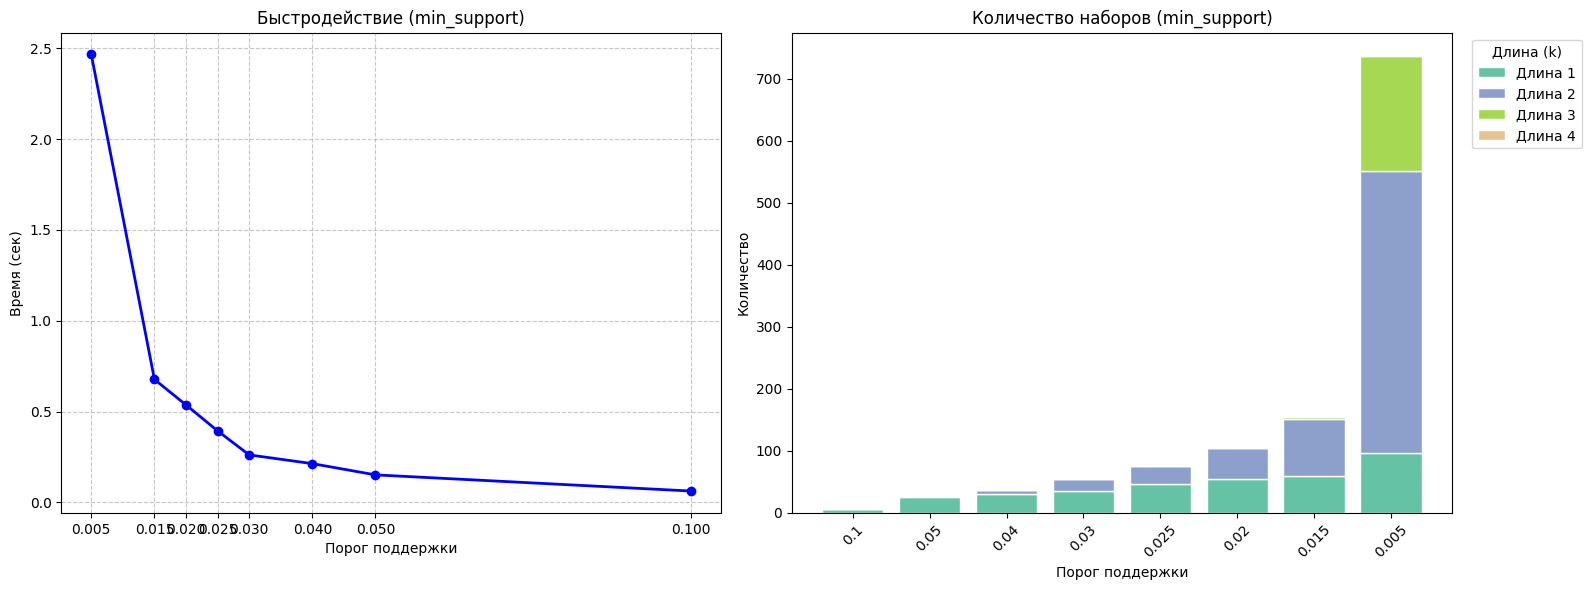


[Confidence] Поиск частых наборов (support=0.02)...


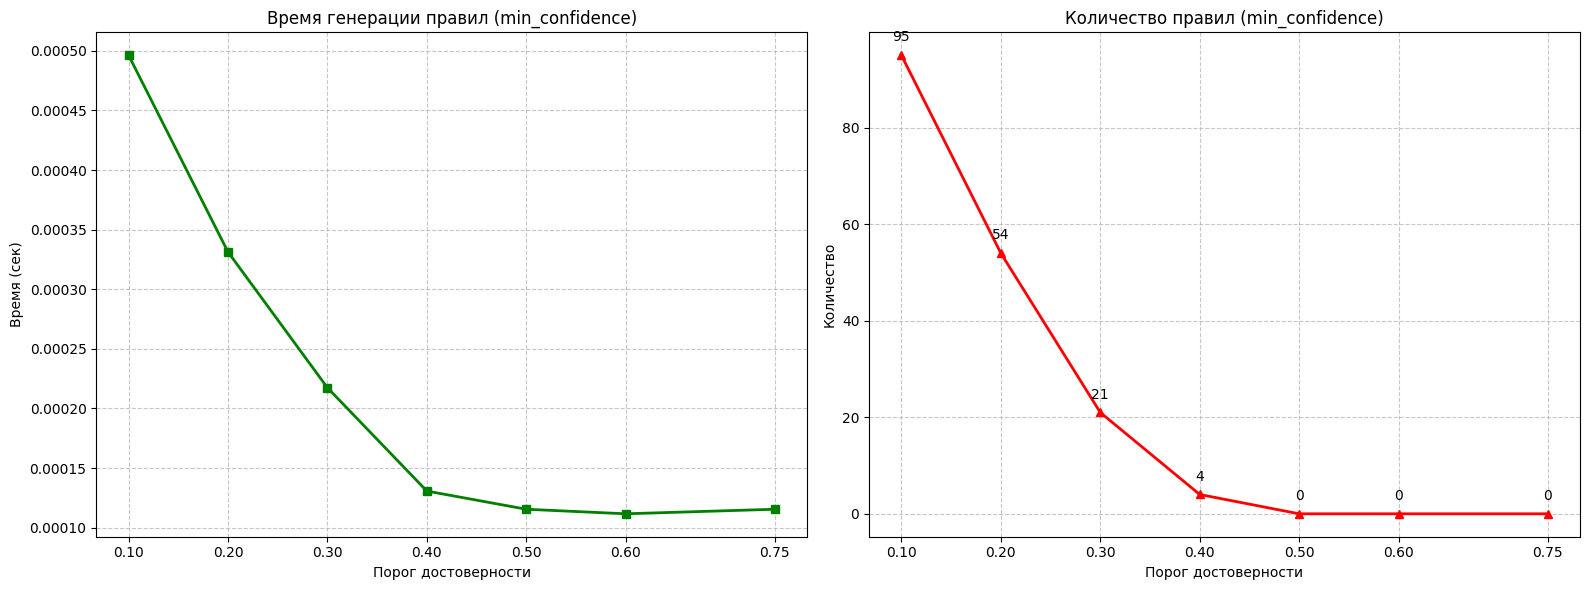

In [39]:
sup_thresholds = [0.1, 0.05, 0.04, 0.03, 0.025, 0.02, 0.015, 0.005]
t1, c1 = run_support_experiments('baskets.csv', sup_thresholds)
plot_support_results(sup_thresholds, t1, c1)

conf_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.75]
t2, c2 = run_confidence_experiments('baskets.csv', fixed_support=0.02, thresholds=conf_thresholds)
plot_confidence_results(conf_thresholds, t2, c2)